# Exploitation de données électorales avec Python

## Import des données

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartiflette

In [5]:
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)
print(f"Shape : {df.shape}")
df.head()

Shape : (528675, 7)


/tmp/ipykernel_18316/3312880608.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## 1. Explorations générales

### Question 1

#### modification de la variable `code_commune`

In [6]:
from rep.explorations_generales import taille_max_code_commune, nb_occurence_longueur_code_departement, departement_11_caractères, maj_code_commune, verification_Montrouge

In [7]:
taille_max_code_commune(df)

La taille maximale du code commune est de 3 caractères.


In [8]:
nb_occurence_longueur_code_departement(df)
print("")
departement_11_caractères(df)

code_departement
2     522300
3       3225
11      3150
Name: count, dtype: int64

Valeurs suspectes dans code_departement :
['fr_etranger']

Extrait des lignes correspondantes :
      code_departement              libelle_departement  code_commune  \
35035      fr_etranger  Français établis hors de France             1   
35036      fr_etranger  Français établis hors de France             2   
35037      fr_etranger  Français établis hors de France             3   
35038      fr_etranger  Français établis hors de France             4   
35039      fr_etranger  Français établis hors de France             6   

      libelle_commune    prenom      nom  voix  
35035         Abidjan  Nathalie  ARTHAUD     7  
35036       Abou Dabi  Nathalie  ARTHAUD     4  
35037           Abuja  Nathalie  ARTHAUD     0  
35038           Accra  Nathalie  ARTHAUD     0  
35039     Addis Abeba  Nathalie  ARTHAUD     1  


Pour créer un `code_commune` unique, nous mettons d’abord le code commune sur 3 chiffres (en ajoutant des zéros à gauche), puis nous le concaténons au code département.

Cette méthode couvre les 4 cas du dataset :
- Classique : Code à 5 chiffres, `92` + `049` → `92049`
- Outre-mer : Code à 6 chiffres, `971` + `001` → `971001`
- Corse (avec lettre) : Code contenant une lettre, `2A` + `001` → `2A001`
- Étranger : Texte suivi de 3 chiffres, `fr_etranger` + `001` → `fr_etranger001`

In [9]:
maj_code_commune(df)
verification_Montrouge(df)

Exemple Montrouge :
      code_commune libelle_commune
34535        92049       Montrouge


#### création de la variable `candidat`


In [10]:
from rep.explorations_generales import entites_uniques, creation_candidat, aperçu_des_candidats

In [11]:
entites_uniques(df)

              nom    prenom
0         ARTHAUD  Nathalie
1   DUPONT-AIGNAN   Nicolas
2         HIDALGO      Anne
3           JADOT   Yannick
4        LASSALLE      Jean
5          LE PEN    Marine
6          MACRON  Emmanuel
7       MÉLENCHON  Jean-Luc
8          POUTOU  Philippe
9        PÉCRESSE   Valérie
10        ROUSSEL    Fabien
11        ZEMMOUR      Éric
12    abstentions       NaN
13         blancs       NaN
14           nuls       NaN


Remarquons que les abstentions, votes blancs et votes nuls sont structurés de la même façon : le type de vote en nom et NaN en prénom. Il est important de prendre en compte cette structure afin d'éviter que ces votes se transforment en NaN.

In [12]:
creation_candidat(df)
aperçu_des_candidats(df)


Aperçu des candidats :
['Nathalie ARTHAUD' 'Fabien ROUSSEL' 'Emmanuel MACRON' 'Jean LASSALLE'
 'Marine LE PEN' 'Éric ZEMMOUR' 'Jean-Luc MÉLENCHON' 'Anne HIDALGO'
 'Yannick JADOT' 'Valérie PÉCRESSE' 'Philippe POUTOU'
 'Nicolas DUPONT-AIGNAN' 'abstentions' 'blancs' 'nuls']


In [13]:
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


Le code commune est bien mis à jour et la variable candidat créée.

### Question 2

In [14]:
from rep.explorations_generales import filtrer_candidats, nb_candidats

Afin d'exprimer le nombre de candidats, il est important de ne pas compter les votes non exprimés et les abstentions. C'est pourquoi la première étape a été de filtrer la base de données.

In [15]:
df_candidats_uniquement = filtrer_candidats(df)
nb_candidats(df_candidats_uniquement)

En 2022, il y avait 12 candidats à l'élection présidentielle.

Liste des candidats :
  - Nathalie ARTHAUD
  - Fabien ROUSSEL
  - Emmanuel MACRON
  - Jean LASSALLE
  - Marine LE PEN
  - Éric ZEMMOUR
  - Jean-Luc MÉLENCHON
  - Anne HIDALGO
  - Yannick JADOT
  - Valérie PÉCRESSE
  - Philippe POUTOU
  - Nicolas DUPONT-AIGNAN


### Question 3


In [16]:
from rep.explorations_generales import scores_nationaux, tableau_scores_nationaux

In [17]:
df_scores_nationaux = scores_nationaux(df_candidats_uniquement)
tableau_scores_nationaux(df_scores_nationaux)

Résultats du premier tour (10 avril 2022)
                 Candidat Nombre votes (total) Score (% votes exprimés)
0         Emmanuel MACRON            9 783 058                   27.85%
1           Marine LE PEN            8 133 828                   23.15%
2      Jean-Luc MÉLENCHON            7 712 520                   21.95%
3            Éric ZEMMOUR            2 485 226                    7.07%
4        Valérie PÉCRESSE            1 679 001                    4.78%
5           Yannick JADOT            1 627 853                    4.63%
6           Jean LASSALLE            1 101 387                    3.13%
7          Fabien ROUSSEL              802 422                    2.28%
8   Nicolas DUPONT-AIGNAN              725 176                    2.06%
9            Anne HIDALGO              616 478                    1.75%
10        Philippe POUTOU              268 904                    0.77%
11       Nathalie ARTHAUD              197 094                    0.56%


## 2. Comparaison des scores départements aux moyennes nationales

### Question 4

In [18]:
from rep.comparaison_des_scores import calculer_score_departements, verifier_resultats_aude_q4

In [19]:
score_departements = calculer_score_departements(df_candidats_uniquement)
verifier_resultats_aude_q4(score_departements)

Vérification pour l'Aude (dept 11) :
    code_departement               candidat  votes   score
125               11          Marine LE PEN  64027  30.14%
121               11        Emmanuel MACRON  43104  20.29%
124               11     Jean-Luc MÉLENCHON  42039  19.79%
131               11           Éric ZEMMOUR  18434   8.68%
123               11          Jean LASSALLE  12382   5.83%
129               11       Valérie PÉCRESSE   7350   3.46%
130               11          Yannick JADOT   6322   2.98%
120               11           Anne HIDALGO   6166   2.90%
122               11         Fabien ROUSSEL   5622   2.65%
127               11  Nicolas DUPONT-AIGNAN   4206   1.98%
128               11        Philippe POUTOU   1748   0.82%
126               11       Nathalie ARTHAUD   1026   0.48%


### Question 5

In [20]:
from rep.comparaison_des_scores import comparer_scores_departementaux_nationaux, verifier_resultats_aude_q5

In [21]:
score_departements = comparer_scores_departementaux_nationaux(df_scores_nationaux,score_departements)
verifier_resultats_aude_q5(score_departements)


Vérification Question 5 - Département 11 (Aude) :
code_departement              candidat  votes_departement score_departement  votes_national score_national
              11         Marine LE PEN              64027            30.14%         8133828         23.15%
              11       Emmanuel MACRON              43104            20.29%         9783058         27.85%
              11    Jean-Luc MÉLENCHON              42039            19.79%         7712520         21.95%
              11          Éric ZEMMOUR              18434             8.68%         2485226          7.07%
              11         Jean LASSALLE              12382             5.83%         1101387          3.13%
              11      Valérie PÉCRESSE               7350             3.46%         1679001          4.78%
              11         Yannick JADOT               6322             2.98%         1627853          4.63%
              11          Anne HIDALGO               6166             2.90%          616478  

### Question 6

La variable `surrepresentation` permet de comparer, en relatif, les scores départementaux par rapport à la moyenne nationale. Elle se calcule selon la formule suivante :
$$Surrepr\acute{e}sentation (\%) = \frac{Score_{dept} - Score_{national}}{Score_{national}} \times 100$$

**Exemple concret :**
Si un candidat obtient **30%** dans un département mais seulement **15%** au niveau national, sa surreprésentation est de :
$$\frac{30 - 15}{15} \times 100 = 100\%$$
Le candidat est donc deux fois plus présent dans ce département que dans l'ensemble du pays.

In [22]:
from rep.comparaison_des_scores import creation_surrepresentation, apercu_surrepresentation

In [23]:
creation_surrepresentation(score_departements)
apercu_surrepresentation(score_departements)

Aperçu avec la variable surrepresentation :
  code_departement               candidat  score_departement  score_national  \
0               01           Anne HIDALGO               1.69            1.75   
1               01        Emmanuel MACRON              27.69           27.85   
2               01         Fabien ROUSSEL               1.78            2.28   
3               01          Jean LASSALLE               3.27            3.13   
4               01     Jean-Luc MÉLENCHON              17.37           21.95   
5               01          Marine LE PEN              26.05           23.15   
6               01       Nathalie ARTHAUD               0.50            0.56   
7               01  Nicolas DUPONT-AIGNAN               2.70            2.06   
8               01        Philippe POUTOU               0.65            0.77   
9               01       Valérie PÉCRESSE               5.28            4.78   

   surrepresentation  
0              -3.43  
1              -0.57  
2     

### Question 7

In [24]:
from rep.comparaison_des_scores import plot_surrepresentation

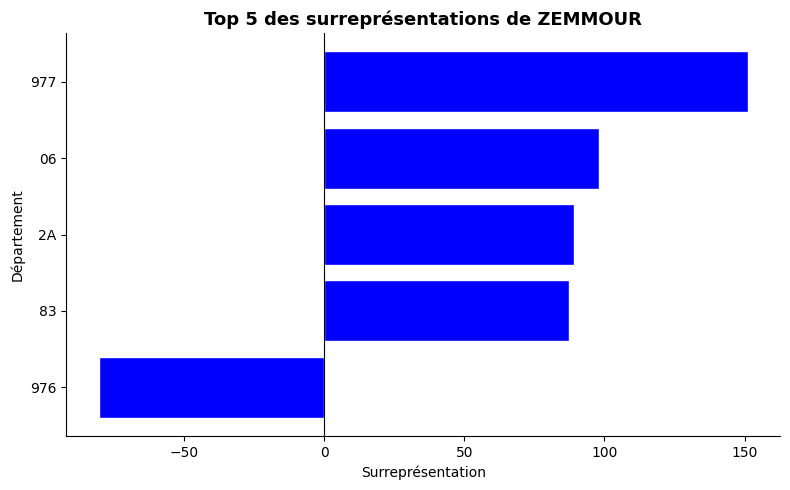

In [25]:
plot_surrepresentation(score_departements,'Éric ZEMMOUR')

## 3. Un peu de cartographie

### Question 8

In [26]:
from cartiflette import carti_download
departement_borders = carti_download(
 values = ["France"],
 crs = 4326,
 borders = "DEPARTEMENT",
 vectorfile_format="geojson",
 simplification=50,
 filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
 source="EXPRESS-COG-CARTO-TERRITOIRE",
 year=2022)

Fonction pour filtrer score_departement

In [27]:
def filtrer_candidat(score_departements, candidat):
    """
    Retourne un nouveau dataframe restreint à un candidat.
    Ne modifie pas score_departements.
    """
    return score_departements.loc[
        score_departements["candidat"] == candidat
    ].copy()

Test pour Marine Le Pen

In [28]:
score_mlp = filtrer_candidat(score_departements, "Marine LE PEN")
score_mlp.head()

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
5,01,Marine LE PEN,86755,26.05,8133828,23.15,12.53
17,02,Marine LE PEN,104342,39.25,8133828,23.15,69.55
29,03,Marine LE PEN,50315,27.06,8133828,23.15,16.89
41,04,Marine LE PEN,26010,26.90,8133828,23.15,16.20
53,05,Marine LE PEN,19696,22.84,8133828,23.15,-1.34


Identifier la bonne colonne

In [31]:
def trouver_colonne_departement(gdf):
    candidats = ["code_departement", "CODE_DEPT", "INSEE_DEP", "DEP", "id"]
    for col in candidats:
        if col in gdf.columns:
            return col
    raise ValueError("Impossible de trouver la colonne du code département dans le fond de carte.")

Fonction de cartographie

In [ ]:

def cartographier_candidat(score_departements, departement_borders, candidat):
    # filtrage du candidat
    df_candidat = score_departements.loc[
        score_departements["candidat"] == candidat,
        ["code_departement", "candidat", "surrepresentation"]
    ].copy()

    # harmonisation des types
    df_candidat["code_departement"] = df_candidat["code_departement"].astype(str).str.zfill(2)

    gdf = departement_borders.copy()
    col_dep = trouver_colonne_departement(gdf)
    gdf[col_dep] = gdf[col_dep].astype(str).str.zfill(2)

    # jointure
    carte = gdf.merge(
        df_candidat,
        left_on=col_dep,
        right_on="code_departement",
        how="left"
    )

    # bornes symétriques pour une palette centrée sur 0
    vmax = carte["surrepresentation"].abs().max()

    # graphique
    fig, ax = plt.subplots(figsize=(10, 10))
    carte.plot(
        column="surrepresentation",
        cmap="bwr",
        linewidth=0.8,
        edgecolor="black",
        legend=True,
        vmin=-vmax,
        vmax=vmax,
        missing_kwds={"color": "lightgrey", "label": "Données manquantes"},
        ax=ax
    )

    ax.set_title(f"Surreprésentation de {candidat} par département", fontsize=14)
    ax.axis("off")
    plt.show()

    return carte

Execution pour Marine Le Pen

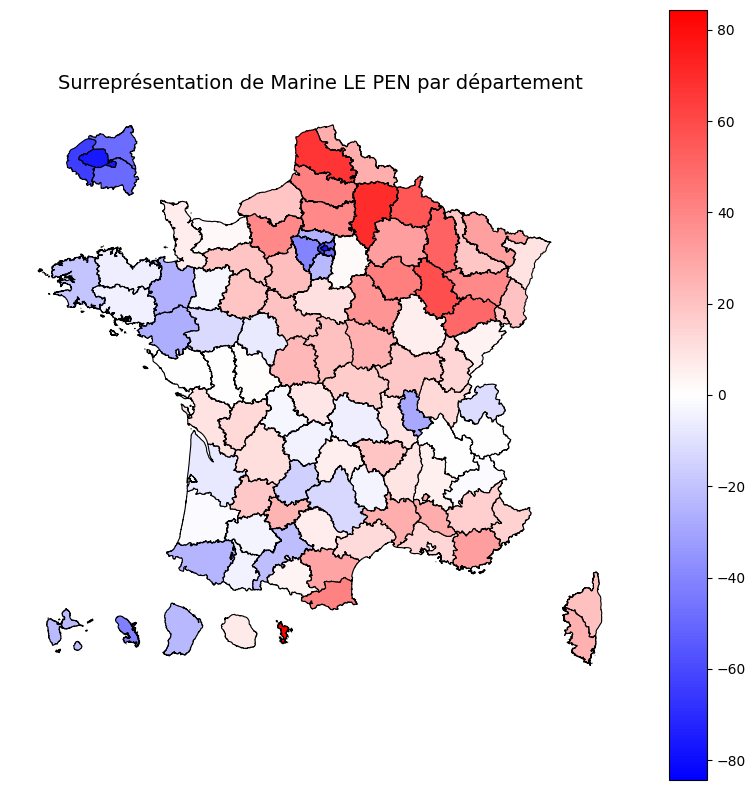

In [33]:
carte_mlp = cartographier_candidat(score_departements, departement_borders, "Marine LE PEN")

Pour d'autres candidats

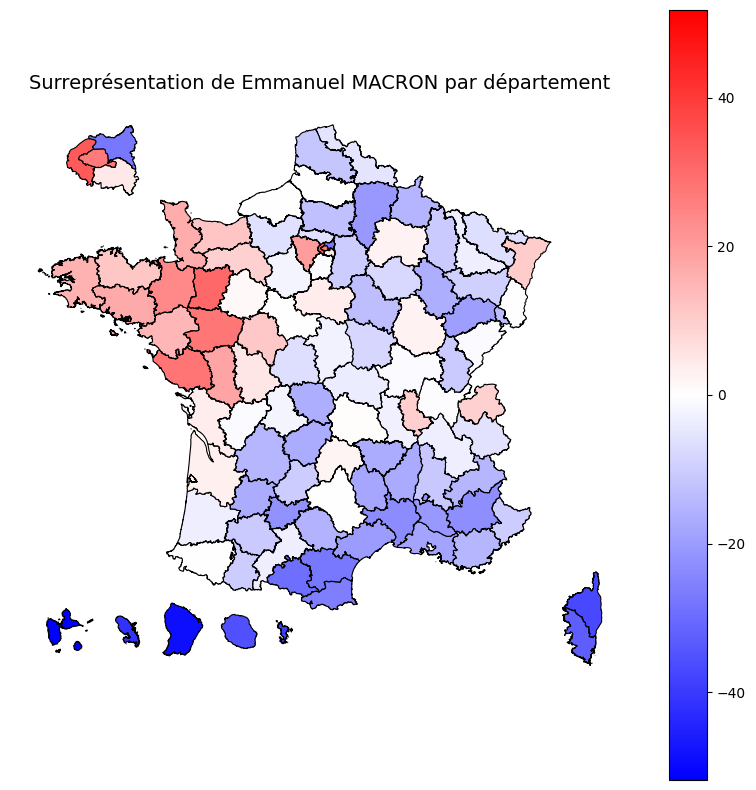

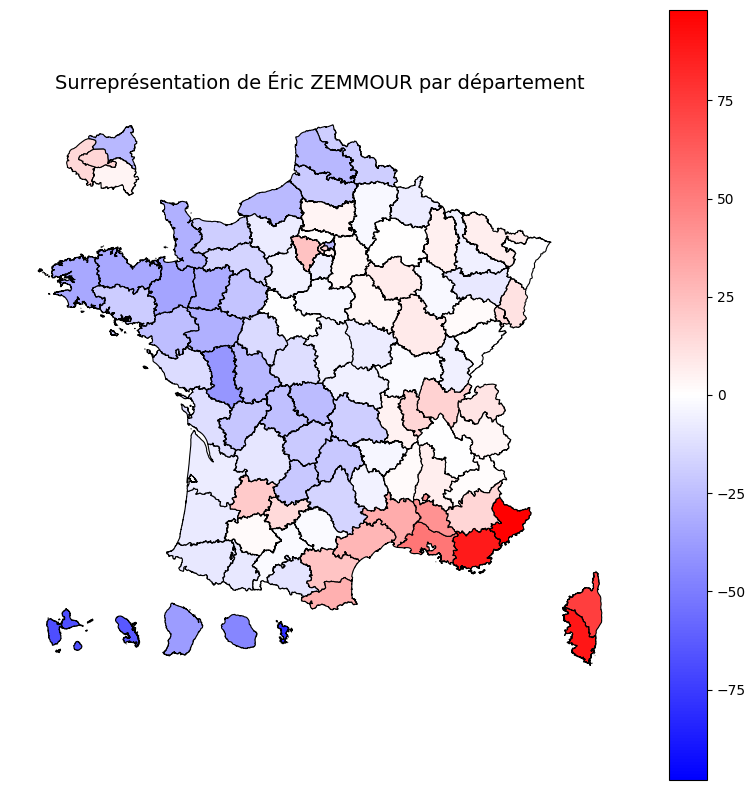

In [47]:
carte_macron = cartographier_candidat(score_departements, departement_borders, "Emmanuel MACRON")
carte_zemmour = cartographier_candidat(score_departements, departement_borders, "Éric ZEMMOUR")

On crée d’abord une fonction permettant de restreindre score_departements à un candidat donné, sans modifier l’objet initial. On applique ensuite cette fonction à Marine Le Pen, conformément à l’énoncé. Enfin, on réalise une jointure entre ces résultats et le fond de carte des départements afin de représenter la surreprésentation territoriale du vote. Les valeurs positives indiquent que le candidat réalise un score supérieur à sa moyenne nationale dans le département, tandis que les valeurs négatives traduisent une sous-représentation. La carte obtenue doit être similaire aux exemples fournis dans les figures 2, 3 et 4.